In [2]:
from google.colab import files
uploaded = files.upload()

Saving processed.cleveland.data to processed.cleveland (1).data


In [3]:
import pandas as pd

df = pd.read_csv("processed.cleveland.data", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
import pandas as pd

df = pd.read_csv("processed.cleveland.data", header=None)

df.columns = [
'age','sex','cp','trestbps','chol','fbs',
'restecg','thalach','exang','oldpeak',
'slope','ca','thal','target'
]

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.shape

(303, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
df = df.replace('?', pd.NA)

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
# Missing values fill using Median

for col in df.columns:
    if df[col].dtype != 'object':
        df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


<Axes: >

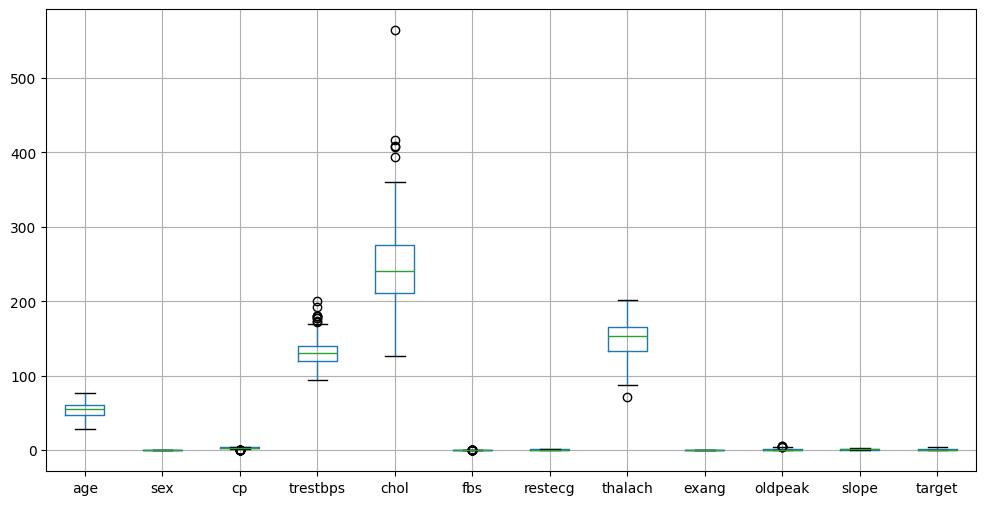

In [10]:
df.boxplot(figsize=(12,6))

In [12]:
# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Outlier removal
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).any(axis=1)]

df.shape

(216, 14)

In [13]:
df["age_group"]=df["age"]//10
df["chol_level"]=df["chol"]/50
df["bp_age_ratio"]=df["trestbps"]/df["age"]

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_level,bp_age_ratio
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,6.0,4.58,1.791045
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,3.0,5.00,3.513514
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,4.0,4.08,3.170732
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0,5.0,4.72,2.142857
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3,6.0,5.36,2.258065


In [14]:
df.to_csv("heart_disease_cleaned.csv", index=False)

In [15]:
import os
os.listdir()

['.config',
 'heart_disease_cleaned.csv',
 'processed.cleveland (1).data',
 'processed.cleveland.data',
 'sample_data']

In [16]:
from google.colab import files
files.download("heart_disease_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_level,bp_age_ratio
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.0,216.000000,216.000000,216.000000,216.000000,216.000000,213.000000,215.000000,216.000000,216.000000,216.000000,216.000000
mean,53.250000,0.662037,3.305556,128.273148,243.268519,0.0,0.916667,150.736111,0.314815,0.899537,1.537037,0.469484,4.590698,0.814815,4.893519,4.865370,2.473475
std,9.100089,0.474115,0.783057,14.849772,45.097952,0.0,0.994169,22.488029,0.465521,1.027324,0.585498,0.683538,1.926186,1.158573,0.946354,0.901959,0.479504
min,29.000000,0.000000,2.000000,94.000000,131.000000,0.0,0.000000,88.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,2.000000,2.620000,1.492537
25%,45.750000,0.000000,3.000000,120.000000,210.750000,0.0,0.000000,137.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,4.000000,4.215000,2.166667
50%,54.000000,1.000000,4.000000,130.000000,240.000000,0.0,0.000000,155.000000,0.000000,0.600000,1.000000,0.000000,3.000000,0.000000,5.000000,4.800000,2.400000
75%,60.000000,1.000000,4.000000,140.000000,271.000000,0.0,2.000000,168.000000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000,6.000000,5.420000,2.727273
max,76.000000,1.000000,4.000000,170.000000,360.000000,0.0,2.000000,202.000000,1.000000,4.000000,3.000000,2.000000,7.000000,4.000000,7.000000,7.200000,4.482759


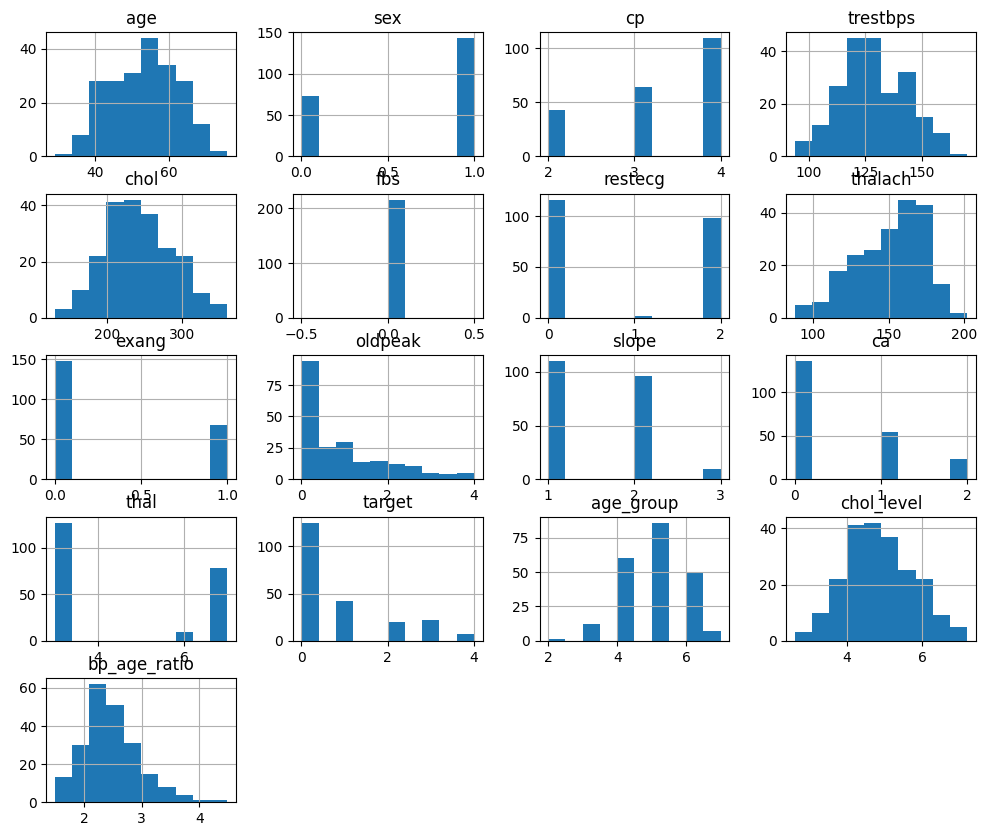

In [18]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

In [19]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_level,bp_age_ratio
age,1.000000,-0.069803,0.183086,0.246206,0.184853,NaN,0.143694,-0.407738,0.161396,0.233746,0.152767,0.411483,0.214664,0.231166,0.955816,0.184853,-0.791875
sex,-0.069803,1.000000,0.141637,-0.004004,-0.094060,NaN,0.028781,-0.097397,0.210346,0.197347,0.020168,0.119994,0.443760,0.325842,-0.090945,-0.094060,0.057583
cp,0.183086,0.141637,1.000000,0.041988,-0.000622,NaN,0.158327,-0.378916,0.449413,0.318174,0.208532,0.278066,0.367989,0.442042,0.188468,-0.000622,-0.154180
trestbps,0.246206,-0.004004,0.041988,1.000000,0.122869,NaN,0.127255,-0.015800,0.009706,0.147724,0.016752,0.016778,0.106945,0.104333,0.249314,0.122869,0.358130
chol,0.184853,-0.094060,-0.000622,0.122869,1.000000,NaN,0.105901,0.006748,0.032288,-0.012878,-0.067667,0.114349,-0.003718,-0.008391,0.166433,1.000000,-0.119836
fbs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,0.143694,0.028781,0.158327,0.127255,0.105901,NaN,1.000000,-0.090238,0.087099,0.147512,0.125185,0.111246,0.024958,0.216712,0.133891,0.105901,-0.063541
thalach,-0.407738,-0.097397,-0.378916,-0.015800,0.006748,NaN,-0.090238,1.000000,-0.475864,-0.392775,-0.427926,-0.293949,-0.419280,-0.450684,-0.406086,0.006748,0.382038
exang,0.161396,0.210346,0.449413,0.009706,0.032288,NaN,0.087099,-0.475864,1.000000,0.367932,0.315380,0.237397,0.389486,0.427677,0.171465,0.032288,-0.148486
oldpeak,0.233746,0.197347,0.318174,0.147724,-0.012878,NaN,0.147512,-0.392775,0.367932,1.000000,0.527782,0.357466,0.338044,0.548971,0.257812,-0.012878,-0.127644


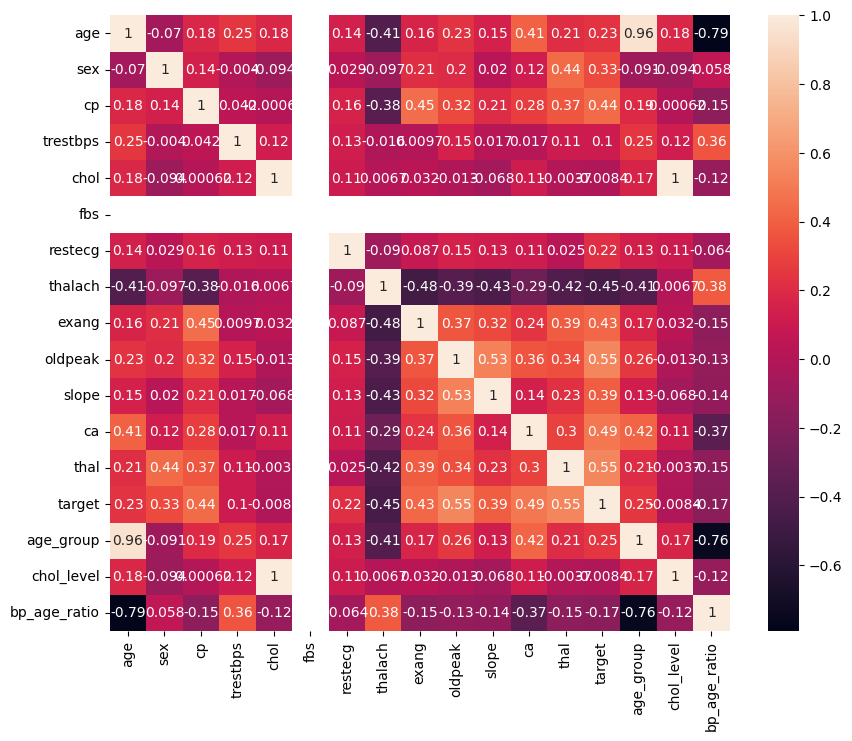

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)

plt.show()

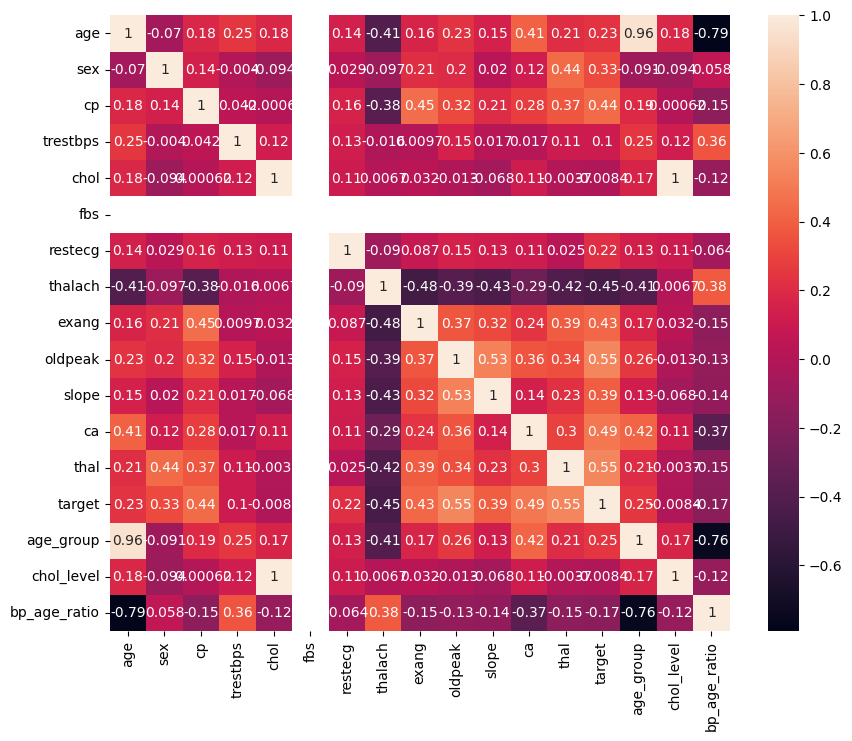

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)

plt.show()

In [22]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

Dataset Shape: (216, 17)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'age_group',
       'chol_level', 'bp_age_ratio'],
      dtype='object')
